# Squares by shrinking every other PAIR of edges

Every polygon is a 16-gon at `kappa = P/sqrt(A) = 4` whose edges run in consecutive **pairs**,
alternating short-pair, long-pair. Holding the perimeter makes the long edge a function of the short
one,

    4(2s) + 4(2l) = P    =>    l = 2P/n - s,

so a polygon's target set is `(A, P, s)` and fixing area and perimeter leaves **one free number**.
Its dimensionless form `u = s / (2P/n)` is `1/2` when every edge is equal and `0` at the end.

**Each long pair is bent to a right angle.** Cam's condition is that a pair's two ends sit `sqrt(2)`
times its edge length apart. For a pair the two edges are equal, so the existing scale-free flatness

    d / (a + b) = cos(theta/2)        theta = the TURNING angle

is exactly `d / (2 l)`, and `d = sqrt(2) l` is `d/(a+b) = 1/sqrt(2) = 0.70710678`. So the corner is
the **flatten family repointed** -- an FD-verified Jacobian already in the code, dimensionless, so it
holds while the polygon sizes are still free. `RIGHT_ANGLE` is an interior point of `d/(a+b)`, unlike
the bound at 1 where a flatten-to-straight ramp runs out of gradient, so this target is *met*.

Shorts gone + corners square **is** a square, so one ramp gets there. Short edges are drawn **blue**,
long ones **red**.

---

## Does it work? Yes, with three corrections, all measured

**1. The right angle goes on the LONG pairs only.** On *every* pair the target set is empty at every
`u > 0`: a pair with equal edges `a` and ends `sqrt(2) a` apart is a rigid right-angled V (chord
`sqrt(2) a`, own triangle `a^2/2`), so the polygon is a closed chain of eight rigid Vs and its
largest possible area is computable. The shortfall against `A0 = 4 p^2` is exactly `4 (2 - sqrt2) s l`
-- at `u = 1/2` the best such 16-gon encloses `(2 + sqrt2) p^2 = 3.414 p^2` against a target of
`4 p^2`, **15% short**. With the right angle on the long pairs only it is feasible everywhere.

**2. The corner is PINNED at 90 degrees, not ramped.** This overturns what I proposed. Four
schedules, 30 rounds, `u` walking 0.5 -> 0.003, worst `max|C|` over the whole ramp:

| corner schedule | spring step | worst max&#124;C&#124; | outcome |
|---|---|---|---|
| pinned at 90 | on | **5.2e-13** | u reached 0.00300 on both polygons |
| pinned at 90 | off | 1.4e-01 | lost at t = 0.53 |
| open to 0.93, then close | on | 7.1e+01 | lost at t = 0.50 |
| 0.85 -> 90 linear | on | 9.2e+01 | lost at t = 0.70 |
| straight -> 90 | on | 2.4e+01 | lost at t = 0.53 |

Anything that moves the corner away from 90 and back loses the retraction, because **the seed already
is a square**: with the corners flat the four sharp vertices have to migrate to the short-pair middles
and then migrate back, which is a rearrangement rather than a ramp.

**3. The spring step is not optional.** Same pinned schedule without `relaxShapes` between rounds:
lost halfway. That is Cam's "minimize each shape with a spring potential" step, and it is load-bearing.

### So where does the compliance come from?

From `u`, and it withdraws itself. Maximum area of the 16-gon at kappa 4 against its target `4 p^2`,
corners at 90:

| u | 0.5 | 0.3 | 0.2 | 0.1 | 0.05 |
|---|---|---|---|---|---|
| slack | +2.9% | +0.66% | +0.20% | +0.025% | +0.003% |

about `u^3 / 4`. The polygon keeps 8 shape degrees of freedom throughout, but the area row pinches
them as `u` falls, so driving `u` down withdraws the shape freedom **continuously** and lands on the
square. Nothing ever goes infeasible -- the square itself satisfies the set at every `u`, with the
short pairs lying straight along its sides.

### And the vertex count

`16 -> 8 -> 4` still happens, but with **one ramp**, not two. A short pair brings three vertices
together, so `halveNumEdges(criterion = "short")` drops two of every four; what is left is a square
carrying four collinear midpoints, which the **existing** flat test removes exactly. Measured on the
free-space chain: area lost 0.0000%, final corners `|turn - 90| = 0.0000` degrees, kappa 4.000000.

---

## Remaining holes

**a. `generateEquilateralPolygons(kappa = 4)` returns self-intersecting polygons.** The springs hold
edge lengths and the *signed* shoelace area, and a folded star satisfies both. Measured: 5/5 polygons
folded at every count, total |turning angle| **468 deg at n = 8, 719 at n = 16, 1089 at n = 32**
against 360 for a simple polygon. At n = 4 the target set has a unique solution and the build lands on
it, so this notebook builds **squares** and calls `doubleNumEdges(2)`. Worth checking against
`annealNgonMorph`, which builds 32-gons this way.

**b. THE CONTACT LAW IS NON-MONOTONIC PAST HALF OVERLAP, and that is what broke the density
controller.** Penetration depth is the shortest translation that separates two shapes, so once one has
passed more than halfway through its neighbour the shorter way out is the far side: the energy peaks
near half overlap and *falls* toward full interpenetration. Two 16-gons at kappa 4, walking one across
the other:

| offset / side | 0.00 | 0.25 | 0.50 | 0.75 |
|---|---|---|---|---|
| pair overlap | 0.0833 | 0.0706 | 0.0467 | 0.0000 |
| pair energy | 4.07e-06 | 2.71e-05 | **1.23e-04** | 3.84e-05 |

A fully stacked pair is a genuine force-balanced **minimum**, not a violation -- which is why an
earlier run sat at `max|F| = 7e-10` with a third of the box double-covered, read its excess as ~0, and
let `holdExcessEnergy` compress to **phi 1.2963** hunting energy that never arrives. The fix is
`placeOnGrid()`: start overlap-free and never cross the barrier. Measured at phi 0.45 on 5 polygons:

| start | pair overlap before | after relax | holdExcessEnergy -> phi |
|---|---|---|---|
| random centres | 0.134 | **0.259** (worse) | 0.216, excess never shed |
| grid | 0.0045 | **0.000006** | **0.698**, excess 5.1e-05 on target |

The ramp below logs `pairOverlap` every round. If it climbs, the packing has crossed the barrier and
everything after that is meaningless.

**c. `ShapeConstraints.projectPositions` gives up silently.** It returns at `maxIter` with no warning
(the composite version warns). Every diagnosis above had to read `maxResidual` by hand. The ramp below
logs it every round for that reason.

**d. The feasibility guard does not see the corner constraint.** `infeasibleReason` bounds the area by
the regular n-gon's; `getTargetShapeMargin` improves on that with `cyclicArea` of the edge targets but
is still blind to the four right angles. The real law is the `u^3/4` above, and nothing computes it
from a live packing -- so `max|C|` is the honest guard.

**e. The parity is chosen once and stored.** Which phase is "short" is not cosmetic: a doubled square
carries its real corners at index 0 mod 4, and constraining index 3 instead asks every corner to move
three slots -- measured `max|C| = 1.5e+04`, `u` stuck at 0.11. `selectPairCorners()` picks the phase
that is already sharpest and stores it on the packing so the edge mask cannot disagree.

In [1]:
import time

import numpy as np
from matplotlib import pyplot as plt

import pyPolygon as pp
import alternating
import records

## 1. Build squares, double to 16-gons, put them in a pinned unit container

**N = 5, whose optimum is PROVED: side `2 + 1/2 sqrt(2) = 2.70710678`.** Five unit squares cannot
exceed `phi = 0.6823`, so the run has a hard yardstick and a hard guard.

`placeOnGrid()` lays the polygons on a lattice instead of leaving them at the build's random centres.
That is not tidiness -- see hole (b): it decides whether the run can separate at all. `phi0 = 0.45` is
low enough that they fit the lattice without touching; `holdExcessEnergy` compresses from there. The
density is checked **before** anything runs.

The jitter breaks the exact collinearity a doubled square carries. Every measurement quoted above was
taken with it; Gaussian noise rather than a systematic shrink, so nothing is biased.

In [2]:
N = 5
n = 16
kappa = 4.0
rampRounds = 18               # schedule steps; u walks geometrically to uFinal
uFinal = 3e-3                 # where the ramp stops. NOT 0 -- a zero edge target divides by zero
uCap = 0.92                   # clip on the draw: u >= 1 asks for a NEGATIVE long edge
startCv = 0.45                # starting CV of P(t) across polygons
phi0 = 0.9                   # low enough that the polygons FIT the grid; compress from there
jitter = 1e-3                 # of an edge length
spreadSteps = 6               # sub-steps to open the u spread. ONE jump folds the polygons
excess = 5e-3                 # how far above jamming to sit, on POLYGON-POLYGON contact alone
wallStiffness = 100.0
coarseness = 1e3
patience = 1000

print(records.describe(N))
bestKnown = records.bestKnownSide(N)
maxSquarePhi = records.maximumDensity(N)
print(f"densest possible for {N} squares: phi = {maxSquarePhi:.4f}")

packing = pp.Model(N = N, n = 4, seed = 42)
packing.generateEquilateralPolygons(phi = phi0, kappa = kappa)
packing.syncTargetAreas()
packing.doubleNumEdges(int(np.log2(n // 4)))
edge = float(np.mean(packing.getEdgeLengths()))
packing.packing.positions += packing.rng.normal(0.0, jitter * edge,
                                                packing.packing.positions.shape)
# ON A LATTICE, not at the build's random centres -- hole (b). The depth contact law is non-monotonic
# past half overlap, so a pair that starts more than halfway through each other is in a genuine
# minimum and the relaxation pulls it further in.
packing.placeOnGrid()

packing.addShape(np.array([[0, 0], [0, 1], [1, 1], [1, 0]]))
packing.pinVertices(np.arange(packing.getNumVertices())[-4:])
packing.setBoundaryConditions("fixed")
packing.setDepthContact(stiffness = 1.0, wallStiffness = wallStiffness)

asked, ceiling = packing.checkDensityFeasible()
print(f"area targets ask for phi {asked:.4f} against a ceiling of {ceiling:.4f}   "
      f"({100 * asked / ceiling:.1f}% of what can exist)")
print(f"pair overlap off the grid: {packing.getPairOverlapArea():.6f}  "
      f"({100 * packing.getPairOverlapArea() / float(packing.getAreas()[:N].sum()):.2f}% of the "
      f"polygon area) -- this is the number that decides whether the run can separate")

def count():
    """Vertices on polygon 0 -- which rung the cascade is on."""
    return int(np.diff(packing.packing.startIndices)[0])

def side():
    """Container side if every polygon were rescaled to unit area -- comparable to bestKnown."""
    return float(np.sqrt(N / packing.getPackingFraction()))

def outside():
    r = packing.packing.positions.reshape(-1, 2)[:packing.packing.startIndices[N]]
    return int(((r < 0.0) | (r > 1.0)).any(axis = 1).sum())

def turns(polygon):
    starts = np.asarray(packing.packing.startIndices, dtype = int)
    loop = packing.packing.positions.reshape(-1, 2)[starts[polygon]:starts[polygon + 1]]
    behind = loop - np.roll(loop, 1, axis = 0)
    ahead = np.roll(loop, -1, axis = 0) - loop
    return np.degrees(np.arctan2(np.cross(behind, ahead),
                                 np.einsum("ij,ij->i", behind, ahead)))

def corners():
    """Worst |corner turn - 90| in degrees, over the CONSTRAINED corners."""
    mask = np.asarray(packing.packing.diagonalMask, dtype = bool)
    starts = np.asarray(packing.packing.startIndices, dtype = int)
    worst = 0.0
    for p in range(N):
        pick = mask[starts[p]:starts[p + 1]]
        worst = max(worst, float(np.max(np.abs(np.abs(turns(p))[pick] - 90.0))))
    return worst

def folded():
    """Worst total |turning angle|; exactly 360 for a simple polygon, more once it folds -- hole (a)."""
    return max(float(np.abs(turns(p)).sum()) for p in range(N))

def drift():
    """max|C|, the honest feasibility guard -- hole (c): the retraction will not tell you itself."""
    return float(packing.constraints.maxResidual(packing.packing))

n = 5: PROVED optimum is side 2.70710678 = 2 + 1/2 sqrt(2)
densest possible for 5 squares: phi = 0.6823


/home/rdennis/Documents/Code/pyPolygon/model.py:216: UserWarning: phi is large: a polygon spans ~0.60 of the unit box (> 0.5), so the single-image periodic assumption in the overlap machinery may be violated; reduce phi.
  return self.generatePolygons(phi, kappa, edgePolydispersity = 0.0, maxSteps = maxSteps)
/tmp/ipykernel_66861/3567548389.py:31: UserWarning: 
*** the polygons overhang a 3 x 2 lattice ***
    the widest spans 0.6000 against a cell of 0.3333, so neighbouring cells will overlap a little. That is usually harmless -- only a pair more than HALFWAY through each other is trapped -- but check getPairOverlapArea() before minimizing, and start at a lower packing fraction if it is a large fraction of a polygon's area.
  packing.placeOnGrid()
/home/rdennis/Documents/Code/pyPolygon/model.py:1796: UserWarning: 
*** AREA TARGETS ASK FOR MORE THAN CAN EXIST ***
    5 polygons ask for phi 0.899999; the PROVED optimum for that many squares allows 0.682275.
    No arrangement satisfies 

area targets ask for phi 0.9000 against a ceiling of 0.6823   (131.9% of what can exist)
pair overlap off the grid: 0.106540  (11.84% of the polygon area) -- this is the number that decides whether the run can separate


## 2. Pin the corners at 90 degrees, then draw the starting distribution of u

`selectPairCorners()` chooses the phase whose vertices are already sharpest -- the doubled square's
own corners -- and stores it, so the edge mask inherits the same parity (hole e).

`u ~ logNormal(mean = 1/2, CV = 0.45)`, clipped to `(0, uCap)`. Mean `1/2` puts the mean short edge at
`P/16`, with individual polygons spread wide either side; some start with `u > 1/2`, so their "short"
edges are the longer ones, exactly as Cam noted.

**The spread is opened in sub-steps, not in one jump** -- hole (a) biting again, from a different
direction. Going from `u = 1/2` straight to the drawn distribution lets the free-space springs find a
FOLDED minimum, and the constraint set then accepts it: measured total |turning angle| **1080 degrees**
with `max|C| = 4.2e-15` and every corner at exactly 90. Nothing in the target set objects to a
self-intersecting polygon. Walking the same distribution in over four or more sub-steps lands on the
identical `u` with |turn| sum 364.8 degrees:

| sub-steps | 1 | 4 | 10 | 25 |
|---|---|---|---|---|
| \|turn\| sum | **1080.00** | 364.79 | 364.87 | 364.89 |

parity 1   20 corners over 5 polygons   corner target d/(a+b) = 0.70710678
starting u: [0.263  0.364  0.456  0.5711 0.7906]   mean 0.4889  CV 0.3721
  2 of 5 polygons start with their SHORT edges longer than their long ones
  spread 1/6: |turn| sum  361.68 deg   max|C| 1.55e-15
  spread 2/6: |turn| sum  361.65 deg   max|C| 1.89e-15
  spread 3/6: |turn| sum  361.63 deg   max|C| 1.44e-15
  spread 4/6: |turn| sum  361.60 deg   max|C| 1.67e-15
  spread 5/6: |turn| sum  361.58 deg   max|C| 2.00e-15
  spread 6/6: |turn| sum  361.55 deg   max|C| 2.44e-15
realized u: [0.263  0.364  0.456  0.5711 0.7906]
worst |turn| sum 361.6 deg   (360 = simple; hole a)


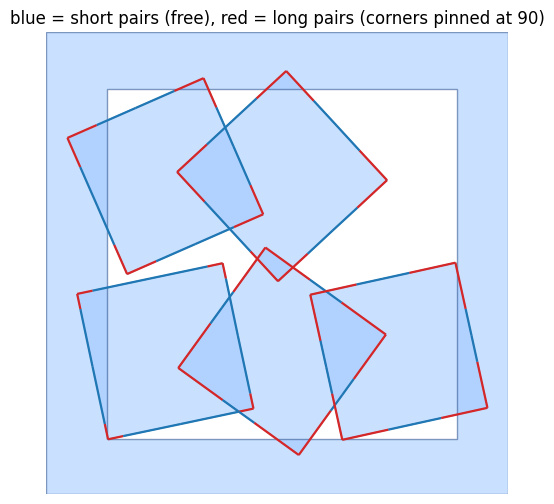

In [3]:
packing.selectPairCorners()
packing.setCornerTargets(alternating.RIGHT_ANGLE)
print(f"parity {int(packing.packing.pairParity)}   "
      f"{int(np.sum(packing.packing.diagonalMask))} corners over {N} polygons   "
      f"corner target d/(a+b) = {alternating.RIGHT_ANGLE:.8f}")

mean, cv = alternating.ratioSchedule(0.0, startMean = 0.5, startCv = startCv, endMean = uFinal)
u0 = np.clip(packing.rng.permutation(alternating.logNormalQuantiles(N, mean, cv)), 1e-6, uCap)
print(f"starting u: {np.array2string(np.sort(u0), precision = 4)}   "
      f"mean {u0.mean():.4f}  CV {u0.std() / u0.mean():.4f}")
print(f"  {(u0 > 0.5).sum()} of {N} polygons start with their SHORT edges longer than their long ones")

# The constraint set goes on FIRST, at u = 1/2, which the doubled square satisfies exactly. Then the
# spread is walked in, so the springs never take a jump big enough to fold a polygon.
packing.setConstraints(area = True, edge = True, flatten = True)
for sub in range(1, spreadSteps + 1):
    packing.setAlternatingEdges(0.5 + (sub / spreadSteps) * (u0 - 0.5))
    packing.relaxShapes(maxSteps = 30000, fThreshold = 1e-12)
    packing.constraints.projectPositions(packing.packing)
    print(f"  spread {sub}/{spreadSteps}: |turn| sum {folded():7.2f} deg   max|C| {drift():.2e}")
print(f"realized u: {np.array2string(np.sort(packing.getAlternatingRatios()), precision = 4)}")
print(f"worst |turn| sum {folded():.1f} deg   (360 = simple; hole a)")

packing.draw(edgeMask = packing.getAlternatingMask())
plt.title("blue = short pairs (free), red = long pairs (corners pinned at 90)")
plt.show()

## 3. First minimization, with every edge held rigid

`setConstraints(area = True, edge = True, flatten = True)`, switched on above, is the whole set: each
edge at its own target, each area at its own, and `d/(a+b) = 1/sqrt(2)` at the four corners. That is
what every minimization from here on uses -- the rank-order transport hands each short edge its own target, so
per-object rows are what hold the scheduled distribution.

`perimeter = True` is deliberately not passed: it is the sum of the edge targets, so its row would be
dependent and `setConstraints` says so. It is held exactly all the same, because `setAlternatingEdges`
splits each short/long pairing to sum to `2P/n`.

**`checkDensityFeasible` will warn here, and at this stage that is a FALSE alarm.** Its ceiling is the
record for N *squares*; these are still compliant 16-gons, a different object that legitimately packs
denser. The warning becomes real only at the end, once the shapes are quadrilaterals. Measured from
the grid start: phi 0.68570, side 2.7003 against the proved optimum 2.70710678 -- 0.26% off, before
the ramp has run at all.

max|C| 2.44e-15   worst |corner - 90| 0.0000 deg   |turn| sum 361.55 deg


FIRE (constrained):  40%|█▏ | 3992/10000 [00:45<01:07, 89.00it/s, maxF=8.05e-05]/home/rdennis/Documents/Code/pyPolygon/model.py:3075: UserWarning: 
*** FIRE stopped at max|F| = 4.03e-05: 1000 steps bought NO reduction at all, and the residual is far above the noise floor (3.0e-12). That is a floor of the ENERGY, not of the minimizer -- a C1 tier has a kink the descent cannot pass, so raise the tolerance or move to a smoother tier rather than spending more steps.

  energy, steps, _ = minimize.minimizeFIRE(
FIRE (constrained):  40%|█▏ | 4000/10000 [00:45<01:08, 87.98it/s, maxF=8.02e-05]


  FIRE   -> max|F| 8.011e-05   stop flat


FIRE (constrained): 100%|███| 2000/2000 [00:19<00:00, 105.13it/s, maxF=2.43e-05]
L-BFGS (constrained):  11%| | 438/4000 [00:07<00:59, 60.05it/s, evalsPerStep=1.5


  L-BFGS -> max|F| 9.769e-10   stop flat
  hold     phi 0.899999  excess 7.5143e-02  (target 5.0000e-03)  pairOverlap 5.677e-02
  hold     phi 0.857142  excess 1.7867e-02  (target 5.0000e-03)  pairOverlap 3.006e-02
  hold     phi 0.848656  excess 1.4478e-02  (target 5.0000e-03)  pairOverlap 2.732e-02
  hold     phi 0.840253  excess 1.1564e-02  (target 5.0000e-03)  pairOverlap 2.474e-02
  hold     phi 0.831934  excess 9.0860e-03  (target 5.0000e-03)  pairOverlap 2.224e-02
  hold     phi 0.823697  excess 7.0058e-03  (target 5.0000e-03)  pairOverlap 1.984e-02
  hold     phi 0.815542  excess 5.2864e-03  (target 5.0000e-03)  pairOverlap 1.755e-02
  hold     phi 0.807467  excess 3.8898e-03  (target 5.0000e-03)  pairOverlap 1.535e-02
  hold     phi 0.814070  excess 5.0100e-03  (target 5.0000e-03)  pairOverlap 1.714e-02

held at excess 5.010e-03:  phi 0.81407  side 2.4783  max|C| 2.22e-15  14 vertices outside


/home/rdennis/Documents/Code/pyPolygon/model.py:1796: UserWarning: 
*** AREA TARGETS ASK FOR MORE THAN CAN EXIST ***
    5 polygons ask for phi 0.814070; the PROVED optimum for that many squares allows 0.682275.
    No arrangement satisfies these targets, so the constraint retraction cannot converge -- a larger maxIter or maxSteps will not help, and the eventual failure will surface far from here as a non-finite force or Jacobian.
    Lower the density before minimizing.
  warnings.warn(


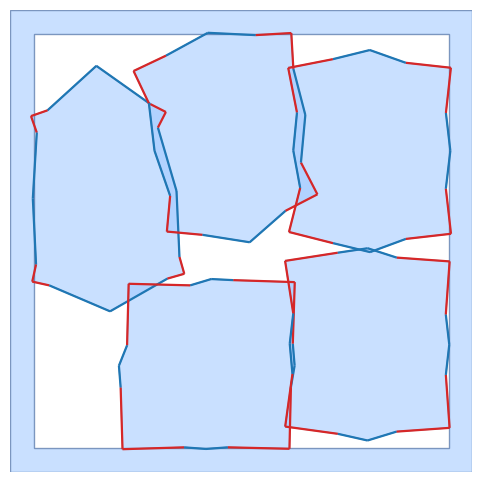

In [4]:
print(f"max|C| {drift():.2e}   worst |corner - 90| {corners():.4f} deg   "
      f"|turn| sum {folded():.2f} deg")

packing.minimizeFIRE(maxUnbalancedForce = 1e-7, maxSteps = 10000, patience = patience,
                     progressBar = "text")
print(f"  FIRE   -> max|F| {packing.getMaxUnbalancedForce():.3e}   stop {packing.getStopReason()}")
packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 4000, coarseness = coarseness,
                          patience = patience, progressBar = "text")
print(f"  L-BFGS -> max|F| {packing.getMaxUnbalancedForce():.3e}   stop {packing.getStopReason()}")

got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", verbose = True)
packing.checkDensityFeasible()
print(f"\nheld at excess {got:.3e}:  phi {phi:.5f}  side {side():.4f}  max|C| {drift():.2e}  "
      f"{outside()} vertices outside")

packing.draw(edgeMask = packing.getAlternatingMask())
plt.show()

## 4. The ramp

Each round:

1. `P(t)` gives the scheduled `(mean, CV)`; the mean walks **geometrically** toward `uFinal`, so the
   last rounds -- where the rows are stiffest and the feasible shell thinnest -- move the targets least.
2. `rankOrderTargets` transports the current `u` onto that schedule by rank. That is `P^-1 . F` with
   `F` the empirical CDF, written in ranks because that form is exact for a finite packing and cannot
   reorder the polygons.
3. `setAlternatingEdges` writes the short targets and sets the long ones to `2P/n - short`, so the
   perimeter is exact by construction.
4. **`relaxShapes`** -- springs only, no overlap, no container -- walks the geometry onto the new
   shape. Without it the retraction is lost halfway; see correction 3.
5. SHAKE retracts onto the manifold, FIRE + L-BFGS relaxes the packing, `holdExcessEnergy` corrects
   the density.

The corner target never moves. `max|C|` is logged every round because nothing else will tell you when
the retraction has given up (hole c).

  round  0/18  asked u 0.48893 -> got 0.48893 (worst 0.79055)  max|C| 3.0e-15  corner 0.000d  phi 0.81407  side 2.4783  |turn| 661  lap 1.71e-02  max|F| 9.1e-10  14 out


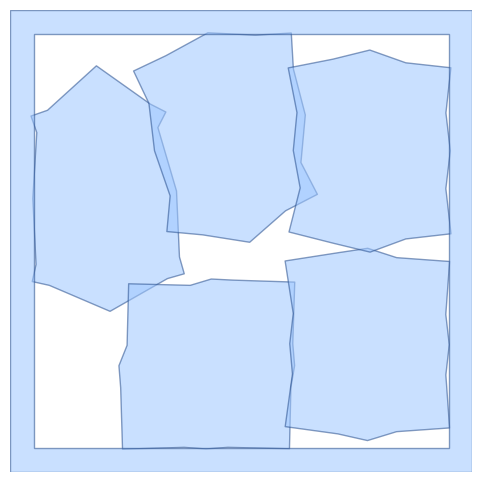

  round  1/18  asked u 0.36882 -> got 0.36882 (worst 0.58381)  max|C| 2.4e-15  corner 0.000d  phi 0.75619  side 2.5714  |turn| 625  lap 1.39e-02  max|F| 9.0e-09  16 out


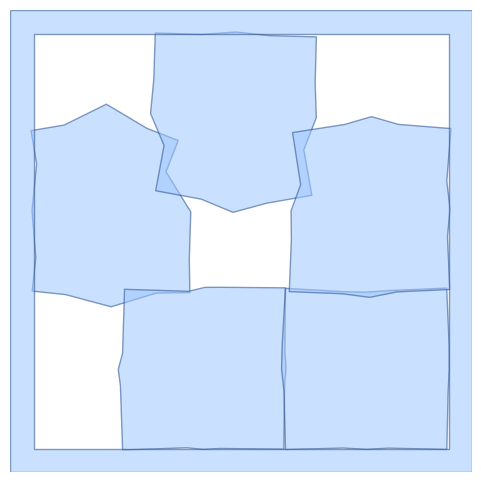

  round  2/18  asked u 0.27818 -> got 0.27818 (worst 0.43081)  max|C| 2.9e-15  corner 0.000d  phi 0.70738  side 2.6586  |turn| 573  lap 9.53e-03  max|F| 8.2e-09  14 out


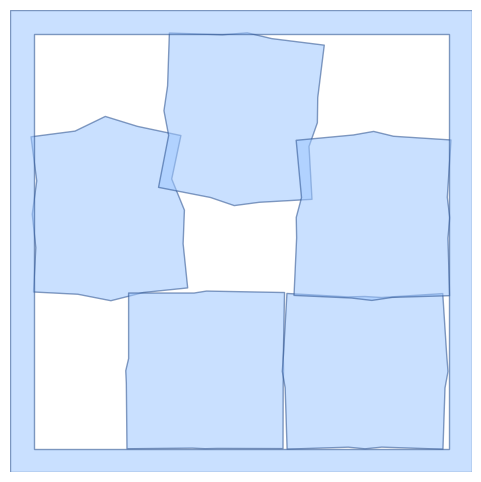

  round  3/18  asked u 0.20980 -> got 0.20980 (worst 0.31767)  max|C| 6.8e-15  corner 0.000d  phi 0.67071  side 2.7303  |turn| 534  lap 8.38e-03  max|F| 7.0e-09  14 out


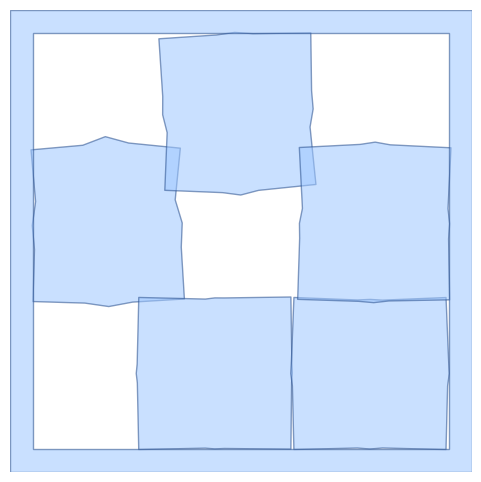

  round  4/18  asked u 0.15821 -> got 0.15821 (worst 0.23406)  max|C| 7.3e-15  corner 0.000d  phi 0.65750  side 2.7576  |turn| 498  lap 8.62e-03  max|F| 4.2e-09  16 out


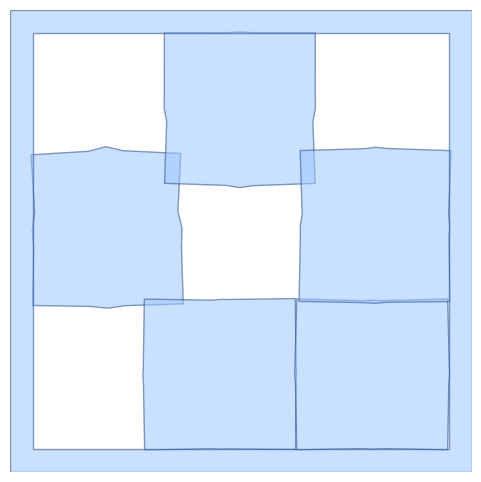

  round  5/18  asked u 0.11929 -> got 0.11929 (worst 0.17233)  max|C| 8.2e-15  corner 0.000d  phi 0.65099  side 2.7714  |turn| 461  lap 8.63e-03  max|F| 8.1e-09  19 out


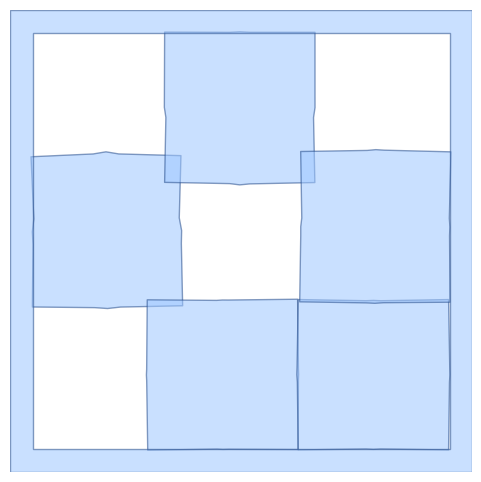

  round  6/18  asked u 0.08993 -> got 0.08993 (worst 0.12677)  max|C| 1.3e-14  corner 0.000d  phi 0.64896  side 2.7757  |turn| 430  lap 8.89e-03  max|F| 6.8e-09  22 out


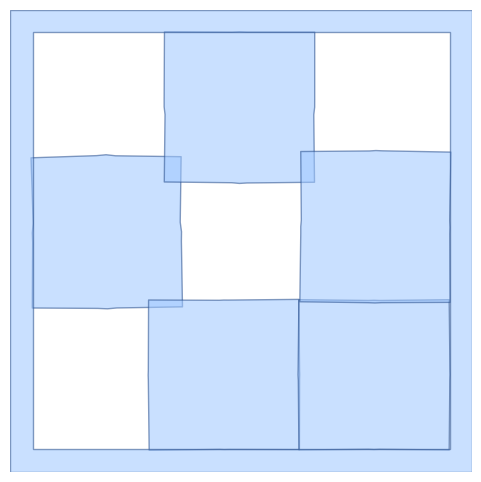

  round  7/18  asked u 0.06779 -> got 0.06779 (worst 0.09319)  max|C| 1.9e-14  corner 0.000d  phi 0.64747  side 2.7789  |turn| 409  lap 8.97e-03  max|F| 4.4e-09  25 out


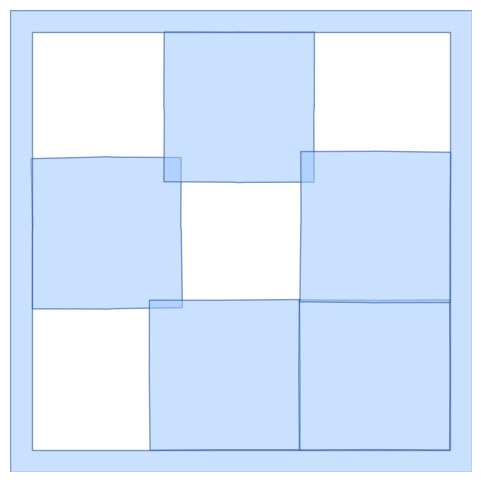

  round  8/18  asked u 0.05109 -> got 0.05109 (worst 0.06845)  max|C| 2.6e-14  corner 0.000d  phi 0.64747  side 2.7789  |turn| 394  lap 9.16e-03  max|F| 9.8e-10  28 out


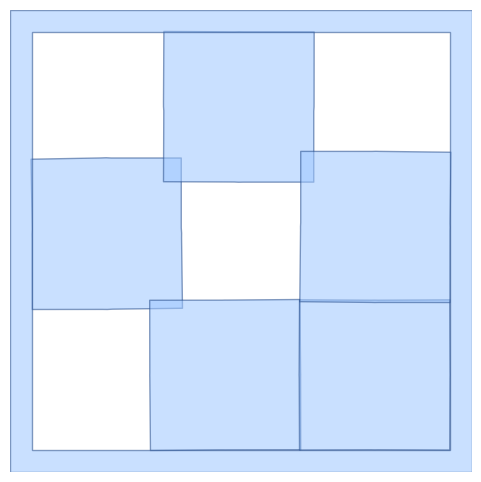

In [ ]:
history = []
start = time.time()
for step in range(rampRounds + 1):
    t = step / rampRounds
    mean, cv = alternating.ratioSchedule(t, startMean = 0.5, startCv = startCv,
                                         endMean = uFinal, endCv = 0.0)
    schedule = alternating.logNormalQuantiles(N, mean, cv)
    target = np.clip(alternating.rankOrderTargets(packing.getAlternatingRatios(), schedule),
                     1e-6, uCap)
    packing.setAlternatingEdges(target)

    packing.relaxShapes(maxSteps = 20000, fThreshold = 1e-12)
    packing.constraints.projectPositions(packing.packing)
    packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 1500,
                              coarseness = coarseness, patience = patience)
    got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", maxRounds = 12,
                                        maxSteps = 1500)

    u = packing.getAlternatingRatios()
    history.append(dict(count = count(), asked = float(np.mean(target)), uMean = float(u.mean()),
                        uMax = float(u.max()), phi = phi, side = side(), drift = drift(),
                        corner = corners(), folded = folded(),
                        overlap = packing.getPairOverlapArea(),
                        force = packing.getMaxUnbalancedForce(), outside = outside()))
    h = history[-1]
    print(f"  round {step:2d}/{rampRounds}  asked u {h['asked']:.5f} -> got {h['uMean']:.5f} "
          f"(worst {h['uMax']:.5f})  max|C| {h['drift']:.1e}  corner {h['corner']:.3f}d  "
          f"phi {h['phi']:.5f}  side {h['side']:.4f}  |turn| {h['folded']:.0f}  "
          f"lap {h['overlap']:.2e}  "
          f"max|F| {h['force']:.1e}  {h['outside']} out", flush = True)
    packing.draw()
    plt.show()

print(f"\nramp took {time.time() - start:.1f} s")
packing.draw(edgeMask = packing.getAlternatingMask())
plt.show()

## 5. Collapse twice, then the endgame

`halveNumEdges(criterion = "short")` drops the two interior vertices of each vanishing short pair --
16 to 8. What is left is a square carrying four collinear midpoints, so the **existing** flat test
takes 8 to 4 exactly.

`setRegularTargets()` then derives `P = 4 sqrt(A)` from each polygon's own area target instead of
carrying the perimeter through the collapses. At n = 4 that puts kappa exactly on its floor, where the
equilateral quadrilateral *is* the square. Carrying the perimeter instead banks the area each collapse
lost as a permanent excess in kappa, and an excess of 0.18% makes `sin theta = (4/kappa)^2` and leaves
the corners at 85.2 degrees.

In [ ]:
areaBefore = packing.getAreas()[:N].copy()
packing.halveNumEdges(criterion = "short")
lost = 1.0 - packing.getAreas()[:N] / areaBefore
print(f"16 -> {count()}:  area lost {100 * np.max(np.abs(lost)):.4f}%   "
      f"worst |corner - 90| {corners():.4f} deg")
packing.setCornerTargets(alternating.RIGHT_ANGLE)
packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 4000, coarseness = coarseness,
                          patience = patience)
got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs")
print(f"  relaxed: phi {phi:.5f}  side {side():.4f}  max|C| {drift():.2e}  {outside()} out")

packing.halveNumEdges(criterion = "flat")
packing.setRegularTargets()
packing.setConstraints(area = True, edge = True)
print(f"{count() * 2} -> {count()}:  now quadrilaterals, targets derived from the area")

packing.minimizeFIRE(maxUnbalancedForce = 1e-7, maxSteps = 20000, patience = patience,
                     progressBar = "text")
packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-10, maxSteps = 8000, coarseness = coarseness,
                          patience = patience)
got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", verbose = True)
packing.checkDensityFeasible()

interior = np.array([np.abs(np.abs(turns(p)) - 90.0).max() for p in range(N)])
print(f"\nFINAL   phi {phi:.6f}   side {side():.6f}   worst |corner - 90| {interior.max():.4f} deg")
print(f"        kappa {np.array2string(packing.getShapeIndices()[:N], precision = 6)}")
print(f"        max|F| {packing.getMaxUnbalancedForce():.3e}   max|C| {drift():.2e}   "
      f"{outside()} vertices outside")
if bestKnown is not None:
    print(f"        record for {N} squares: side {bestKnown:.6f}  "
          f"({100 * (side() / bestKnown - 1):+.3f}% off)")
    print(f"        phi ceiling {maxSquarePhi:.6f} -- anything above it is a broken packing")

packing.draw()
plt.show()

In [ ]:
figure, axes = plt.subplots(1, 4, figsize = (19, 4))
x = np.arange(len(history))
for ax in axes:
    ax.set_xlabel("ramp round")

axes[0].semilogy(x, [h["uMean"] for h in history], marker = "o", label = "mean u")
axes[0].semilogy(x, [h["uMax"] for h in history], marker = ".", label = "worst u")
axes[0].axhline(uFinal, linestyle = "--", color = "0.5", label = "uFinal")
axes[0].set_ylabel("u = short / (2P/n)"); axes[0].legend()

axes[1].semilogy(x, [max(h["drift"], 1e-16) for h in history], marker = "o")
axes[1].axhline(1e-9, linestyle = "--", color = "0.5", label = "give up above here")
axes[1].set_ylabel("max|C| -- the retraction's own health"); axes[1].legend()

axes[2].plot(x, [h["phi"] for h in history], marker = "o")
if maxSquarePhi is not None:
    axes[2].axhline(maxSquarePhi, linestyle = "--", color = "#c0392b",
                    label = f"ceiling for {N} squares")
    axes[2].legend()
axes[2].set_ylabel("phi")

axes[3].semilogy(x, [max(h["overlap"], 1e-16) for h in history], marker = "o",
                 label = "pair overlap area")
axes[3].plot(x, [h["folded"] / 360.0 for h in history], marker = ".",
             label = "|turn| sum / 360 (1 = simple)")
axes[3].set_ylabel("crossed the barrier? folded?"); axes[3].legend()
plt.tight_layout(); plt.show()